# Putting files in vcf format for SpliceAI analysis

- Need to put editing info into VCF format for splice AI
- Example: 19:38958362 C>T
    - chr:location:base_change

    

In [76]:
import numpy as np 
import pandas as pd
from pegg import prime
import Bio.Seq

In [9]:
filepath = '/Users/samgould/Desktop/FSR Lab/reference files/GRCh38/ncbi-genomes-2022-02-23/GCF_000001405.26_GRCh38_genomic.fna.gz'
chrom_dict, i = prime.genome_loader(filepath)

In [145]:
info = pd.read_csv('cluster_scripts/ABE_scripts/STEP3/master_df_HGVSp_quant_pool1_v2.csv')
editing = pd.read_csv('CBE_editing/all_samples_combined_edit.zip')
#editing = pd.read_csv('ABE_screen_data/ABE_editing/ABE_all_samples_combined_edit.zip')

In [146]:
gRNA = 'gRNA_CDK7_targ_227'

def vcf_generator(info, editing):
    df_holder = []
    for idx, gRNA in enumerate(list(info['gRNA_id'])):
        gRNA_chrom = int(info.loc[info['gRNA_id']==gRNA, 'chrom'])
        gRNA_proto_start = int(info.loc[info['gRNA_id']==gRNA, 'proto_start'])
        gRNA_proto_end = int(info.loc[info['gRNA_id']==gRNA, 'proto_end'])
        #gRNA_orientation = info.loc[info['gRNA_id']==gRNA, 'orientation'].values[0]
        gRNA_proto = info.loc[info['gRNA_id']==gRNA, 'protospacer'].values[0]

        edits = editing[editing['gRNA_id']==gRNA]
        if gRNA_proto_start<gRNA_proto_end:
            gRNA_orientation='for'
        elif gRNA_proto_start>gRNA_proto_end:
            gRNA_orientation = 'rev'

        if gRNA_orientation=='for':
            holder = []
            for i, val in enumerate(list(edits['DNA Change'])):
                k = val.split(',')
                for j in k:
                    if j not in ['', 'No edit']:
                        holder.append(j)

            uniq_vars = np.unique(holder)


            assert gRNA_proto == str(chrom_dict[gRNA_chrom][gRNA_proto_start-1:gRNA_proto_end]).upper(), print(gRNA)

            variant_location = []
            variant_orig = []
            variant_mutant = []

            #for forward orientation
            for j in uniq_vars:
                var_loc = int(j[1:-3])
                var_orig = j[-3]
                var_mutant = j[-1]

                true_value = gRNA_proto_start + (var_loc-1)

                assert str(chrom_dict[gRNA_chrom][true_value-1]).upper()==var_orig

                variant_location.append(true_value)
                variant_orig.append(var_orig)
                variant_mutant.append(var_mutant)

            splice_AI = pd.DataFrame(dict(zip(['POS', 'REF', 'ALT'], [variant_location, variant_orig, variant_mutant])))
            splice_AI['CHROM'] = gRNA_chrom
            splice_AI['DNA_edit'] = uniq_vars

            splice_AI = splice_AI[['CHROM', 'POS', 'REF', 'ALT', 'DNA_edit']]

        elif gRNA_orientation=='rev':
            
            holder = []
            for i, val in enumerate(list(edits['DNA Change'])):
                k = val.split(',')
                for j in k:
                    if j not in ['', 'No edit']:
                        holder.append(j)

            uniq_vars = np.unique(holder)


            assert gRNA_proto == str(Bio.Seq.Seq(str(chrom_dict[gRNA_chrom][gRNA_proto_end-1:gRNA_proto_start])).reverse_complement()).upper(), print(gRNA)

            variant_location = []
            variant_orig = []
            variant_mutant = []

            #for forward orientation
            for j in uniq_vars:
                var_loc = int(j[1:-3])
                var_orig = str(Bio.Seq.Seq(j[-3]).reverse_complement())
                var_mutant = str(Bio.Seq.Seq(j[-1]).reverse_complement())

                true_value = gRNA_proto_end + (20-var_loc)

                assert str(chrom_dict[gRNA_chrom][true_value-1]).upper()==var_orig, print(f'{str(chrom_dict[gRNA_chrom][true_value-1])}, {var_orig}')

                variant_location.append(true_value)
                variant_orig.append(var_orig)
                variant_mutant.append(var_mutant)

            splice_AI = pd.DataFrame(dict(zip(['POS', 'REF', 'ALT'], [variant_location, variant_orig, variant_mutant])))
            splice_AI['CHROM'] = gRNA_chrom
            splice_AI['DNA_edit'] = uniq_vars

            splice_AI = splice_AI[['CHROM', 'POS', 'REF', 'ALT', 'DNA_edit']]

        splice_AI['gRNA_id'] = gRNA
        df_holder.append(splice_AI)

        if idx%100==0:
            print(idx)
    
    return pd.concat(df_holder)


In [147]:
vcf_edit = vcf_generator(info, editing)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400


In [148]:
vcf_edit.to_csv('splicing/edits_CBE.csv', index=False)

In [149]:
cbe_uniq_edits = vcf_edit[['CHROM', 'POS', 'REF', 'ALT']].drop_duplicates()

df = cbe_uniq_edits
df['ID'] = "."
df['QUAL'] = 40
df['FILTER'] = "."
df['INFO'] = "."

df = df[['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']] 

header = """##fileformat=VCFv4.2
##fileDate=20250616
##source=ABE_uniq_edits
##contig=<ID=1,length=248956422,assembly=GRCh38>
##contig=<ID=2,length=242193529,assembly=GRCh38>
##contig=<ID=3,length=198295559,assembly=GRCh38>
##contig=<ID=4,length=190214555,assembly=GRCh38>
##contig=<ID=5,length=181538259,assembly=GRCh38>
##contig=<ID=6,length=170805979,assembly=GRCh38>
##contig=<ID=7,length=159345973,assembly=GRCh38>
##contig=<ID=8,length=145138636,assembly=GRCh38>
##contig=<ID=9,length=138394717,assembly=GRCh38>
##contig=<ID=10,length=133797422,assembly=GRCh38>
##contig=<ID=11,length=135086622,assembly=GRCh38>
##contig=<ID=12,length=133275309,assembly=GRCh38>
##contig=<ID=13,length=114364328,assembly=GRCh38>
##contig=<ID=14,length=107043718,assembly=GRCh38>
##contig=<ID=15,length=101991189,assembly=GRCh38>
##contig=<ID=16,length=90338345,assembly=GRCh38>
##contig=<ID=17,length=83257441,assembly=GRCh38>
##contig=<ID=18,length=80373285,assembly=GRCh38>
##contig=<ID=19,length=58617616,assembly=GRCh38>
##contig=<ID=20,length=64444167,assembly=GRCh38>
##contig=<ID=21,length=46709983,assembly=GRCh38>
##contig=<ID=22,length=50818468,assembly=GRCh38>
##contig=<ID=X,length=156040895,assembly=GRCh38>
##contig=<ID=Y,length=57227415,assembly=GRCh38>
##contig=<ID=M,length=16569,assembly=GRCh38>
#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO
"""

output_VCF = "splicing/CBE.vcf"
with open(output_VCF, 'w') as vcf:
    vcf.write(header)

df.to_csv(output_VCF, sep="\t", mode='a', index=False, header=False)



In [127]:
gRNA = 'gRNA_CDK19_targ_6273'



gRNA_chrom = int(info.loc[info['gRNA_id']==gRNA, 'chrom'])
gRNA_proto_start = int(info.loc[info['gRNA_id']==gRNA, 'proto_start'])
gRNA_proto_end = int(info.loc[info['gRNA_id']==gRNA, 'proto_end'])
#gRNA_orientation = info.loc[info['gRNA_id']==gRNA, 'orientation'].values[0]
gRNA_proto = info.loc[info['gRNA_id']==gRNA, 'protospacer'].values[0]

edits = editing[editing['gRNA_id']==gRNA]

if gRNA_proto_start<gRNA_proto_end:
    gRNA_orientation='for'
elif gRNA_proto_start>gRNA_proto_end:
    gRNA_orientation = 'rev'
    
if gRNA_orientation=='for':
    holder = []
    for i, val in enumerate(list(edits['DNA Change'])):
        k = val.split(',')
        for j in k:
            if j not in ['', 'No edit']:
                holder.append(j)

    uniq_vars = np.unique(holder)


    assert gRNA_proto == str(chrom_dict[gRNA_chrom][gRNA_proto_start-1:gRNA_proto_end]).upper(), print(gRNA)

    variant_location = []
    variant_orig = []
    variant_mutant = []

    #for forward orientation
    for j in uniq_vars:
        var_loc = int(j[1:-3])
        var_orig = j[-3]
        var_mutant = j[-1]

        true_value = gRNA_proto_start + (var_loc-1)

        assert str(chrom_dict[gRNA_chrom][true_value-1]).upper()==var_orig

        variant_location.append(true_value)
        variant_orig.append(var_orig)
        variant_mutant.append(var_mutant)

    splice_AI = pd.DataFrame(dict(zip(['POS', 'REF', 'ALT'], [variant_location, variant_orig, variant_mutant])))
    splice_AI['CHROM'] = gRNA_chrom
    splice_AI['DNA_edit'] = uniq_vars

    splice_AI = splice_AI[['CHROM', 'POS', 'REF', 'ALT', 'DNA_edit']]

elif gRNA_orientation=='rev':
    
    holder = []
    for i, val in enumerate(list(edits['DNA Change'])):
        k = val.split(',')
        for j in k:
            if j not in ['', 'No edit']:
                holder.append(j)

    uniq_vars = np.unique(holder)


    assert gRNA_proto == str(Bio.Seq.Seq(str(chrom_dict[gRNA_chrom][gRNA_proto_end-1:gRNA_proto_start])).reverse_complement()).upper()

    variant_location = []
    variant_orig = []
    variant_mutant = []

    #for rev orientation
    for j in uniq_vars:
        var_loc = int(j[1:-3])
        var_orig = str(Bio.Seq.Seq(j[-3]).reverse_complement())
        var_mutant = str(Bio.Seq.Seq(j[-1]).reverse_complement())

        true_value = gRNA_proto_end + (20-var_loc)

        print(var_loc)
        print(gRNA_proto_end)
        print(true_value)

        assert str(chrom_dict[gRNA_chrom][true_value-1]).upper()==var_orig, print(f'{str(chrom_dict[gRNA_chrom][true_value-1])}, {var_orig}')

        variant_location.append(true_value)
        variant_orig.append(var_orig)
        variant_mutant.append(var_mutant)

    splice_AI = pd.DataFrame(dict(zip(['POS', 'REF', 'ALT'], [variant_location, variant_orig, variant_mutant])))
    splice_AI['CHROM'] = gRNA_chrom
    splice_AI['DNA_edit'] = uniq_vars

    splice_AI = splice_AI[['CHROM', 'POS', 'REF', 'ALT', 'DNA_edit']]

splice_AI['gRNA_id'] = gRNA



In [121]:
gRNA_proto

'TGGTCAGTACCGGTGGGCCT'

In [122]:
str(Bio.Seq.Seq(str(chrom_dict[gRNA_chrom][gRNA_proto_end-1:gRNA_proto_start])).reverse_complement()).upper()

''

In [124]:
gRNA_proto_end

110614551

In [125]:
gRNA_proto_start

110614532

In [126]:
gRNA_orientation

'rev'

In [123]:
edits

,Edit,HGVSp,Num_edits,DNA Change,Canonical_edit,Canonical_window,gRNA_id,#Reads,%Reads
1004133,TGGTTAGTACCGGTGGGCCT,WT,20,"+5C>T,",True,True,gRNA_CDK19_targ_6273,80193,71.960051
1004134,TGGTCAGTACCGGTGGGCCT,WT,20,No edit,True,True,gRNA_CDK19_targ_6273,17578,15.773369
1004135,TGGTTAGTACTGGTGGGCCT,R501Q,20,"+5C>T,+11C>T,",True,False,gRNA_CDK19_targ_6273,3144,2.821224
1004136,TGGTAAGTACCGGTGGGCCT,WT,20,"+5C>A,",False,True,gRNA_CDK19_targ_6273,2382,2.137454
1004137,TGGTTAGTATCGGTGGGCCT,WT,20,"+5C>T,+10C>T,",True,False,gRNA_CDK19_targ_6273,1038,0.931435
...,...,...,...,...,...,...,...,...,...
1004468,TTGTGAGTACCGGTGGGCCT,WT,20,"+2G>T,+5C>G,",False,False,gRNA_CDK19_targ_6273,1,0.000897
1004469,TTGTTAGTACCGGTGGGCCG,Q498P,20,"+2G>T,+5C>T,+20T>G,",False,False,gRNA_CDK19_targ_6273,1,0.000897
1004470,TTGTTAGTACTGGTGGGCCT,R501Q,20,"+2G>T,+5C>T,+11C>T,",False,False,gRNA_CDK19_targ_6273,1,0.000897
1004471,TTGTTATTACCGGTGGGCCT,Y502*,20,"+2G>T,+5C>T,+7G>T,",False,False,gRNA_CDK19_targ_6273,1,0.000897


In [55]:
holder = []
for i, val in enumerate(list(edits['DNA Change'])):
    k = val.split(',')
    for j in k:
        if j not in ['', 'No edit']:
            holder.append(j)

uniq_vars = np.unique(holder)
uniq_vars

array(['+10T>A', '+10T>C', '+10T>G', '+11C>A', '+11C>G', '+11C>T',
       '+12T>A', '+12T>C', '+12T>G', '+13G>A', '+13G>C', '+13G>T',
       '+14G>A', '+14G>C', '+14G>T', '+15A>C', '+15A>G', '+15A>T',
       '+16C>A', '+16C>G', '+16C>T', '+17G>A', '+17G>C', '+17G>T',
       '+18T>A', '+18T>C', '+18T>G', '+19G>A', '+19G>C', '+19G>T',
       '+1C>A', '+1C>G', '+1C>T', '+20A>C', '+20A>G', '+20A>T', '+2C>A',
       '+2C>G', '+2C>T', '+3G>A', '+3G>C', '+3G>T', '+4G>A', '+4G>C',
       '+4G>T', '+5A>C', '+5A>G', '+5A>T', '+6T>A', '+6T>C', '+6T>G',
       '+7G>A', '+7G>C', '+7G>T', '+8G>A', '+8G>C', '+8G>T', '+9C>A',
       '+9C>G', '+9C>T'], dtype='<U6')

In [ ]:
s = '+10T>A'
s2 = '+1C>A'

var_loc = int(s[1:-3])
var_orig = s[-3]
var_mutant = s[-1]

'T'

In [38]:
gRNA_proto[10]

'C'

In [23]:
gRNA_proto_end - gRNA_proto_start

19

In [22]:
gRNA_proto_end

69234991

In [17]:
edits

,Edit,HGVSp,Num_edits,DNA Change,Canonical_edit,Canonical_window,gRNA_id,#Reads,%Reads
0,CCGGATGGTTCTGGACGTGA,A2V,20,"+9C>T,",True,False,gRNA_CDK7_targ_1,94978,40.443017
1,CCGGATGGCTTTGGACGTGA,WT,20,"+11C>T,",True,False,gRNA_CDK7_targ_1,35239,15.005280
2,CCGGATGGCTCTGGACGTGA,WT,20,No edit,True,True,gRNA_CDK7_targ_1,18382,7.827324
3,CTGGATGGTTCTGGACGTGA,A2V,20,"+2C>T,+9C>T,",True,False,gRNA_CDK7_targ_1,14309,6.092981
4,CCGGATGGTTTTGGACGTGA,A2V,20,"+9C>T,+11C>T,",True,False,gRNA_CDK7_targ_1,13015,5.541977
...,...,...,...,...,...,...,...,...,...
1163,TTGGATGGTTCTGGACGTGG,A2V_K6E,20,"+1C>T,+2C>T,+9C>T,+20A>G,",False,False,gRNA_CDK7_targ_1,1,0.000426
1164,TTGGATGTTTCTGGACGTGA,A2F,20,"+1C>T,+2C>T,+8G>T,+9C>T,",False,False,gRNA_CDK7_targ_1,1,0.000426
1165,TTGGATGTTTCTGTACGTGA,A2F_D4Y,20,"+1C>T,+2C>T,+8G>T,+9C>T,+14G>T,",False,False,gRNA_CDK7_targ_1,1,0.000426
1166,TTGGATTGCTTTGGACGTGA,M1I,20,"+1C>T,+2C>T,+7G>T,+11C>T,",False,False,gRNA_CDK7_targ_1,1,0.000426


# Processing splice AI output


In [184]:
splice_ABE = pd.read_csv('splicing/output_ABE.vcf', header=30, sep='\t')


for i, val in splice_ABE.iterrows():
    a = val['INFO']
    s = a.split('|')

    splice_ABE.loc[i, 'Gene'] = s[1]
    splice_ABE.loc[i, 'DS_AG'] = np.sqrt(float(s[2])**2)
    splice_ABE.loc[i, 'DS_AL'] = np.sqrt(float(s[3])**2)
    splice_ABE.loc[i, 'DS_DG'] = np.sqrt(float(s[4])**2)
    splice_ABE.loc[i, 'DS_DL'] = np.sqrt(float(s[5])**2)
    splice_ABE.loc[i, 'DP_AG'] = float(s[6])
    splice_ABE.loc[i, 'DP_AL'] = float(s[7])
    splice_ABE.loc[i, 'DP_DG'] = float(s[8])
    splice_ABE.loc[i, 'DP_DL'] = float(s[9])


In [190]:
splice_ABE.sort_values(by='DS_AG', ascending=False)[:29]

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,Gene,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
3797,5,69276541,.,A,G,40,.,SpliceAI=G|CDK7|1.00|1.00|0.00|0.00|1|2|15|1,CDK7,1.00,1.00,0.0,0.0,1.0,2.0,15.0,1.0
17965,6,110626847,.,T,C,40,.,SpliceAI=C|CDK19|1.00|0.96|0.00|0.00|-1|-2|-11|-8,CDK19,1.00,0.96,0.0,0.0,-1.0,-2.0,-11.0,-8.0
3783,5,69276540,.,A,G,40,.,SpliceAI=G|CDK7|1.00|0.12|0.00|0.00|1|3|-5|16,CDK7,1.00,0.12,0.0,0.0,1.0,3.0,-5.0,16.0
3800,5,69276542,.,G,A,40,.,SpliceAI=A|CDK7|1.00|1.00|0.00|0.00|2|1|-7|9,CDK7,1.00,1.00,0.0,0.0,2.0,1.0,-7.0,9.0
17022,6,110670546,.,A,C,40,.,SpliceAI=C|CDK19|1.00|0.67|0.00|0.00|-1|-5|-5|-15,CDK19,1.00,0.67,0.0,0.0,-1.0,-5.0,-5.0,-15.0
3804,5,69276539,.,A,G,40,.,SpliceAI=G|CDK7|1.00|0.13|0.00|0.00|1|4|4|-16,CDK7,1.00,0.13,0.0,0.0,1.0,4.0,4.0,-16.0
12779,9,127786696,.,T,A,40,.,SpliceAI=A|CDK9|1.00|0.00|0.00|0.00|2|5|44|-24,CDK9,1.00,0.00,0.0,0.0,2.0,5.0,44.0,-24.0
12809,9,127787513,.,C,G,40,.,SpliceAI=G|CDK9|1.00|0.36|0.00|0.00|1|18|5|24,CDK9,1.00,0.36,0.0,0.0,1.0,18.0,5.0,24.0
9368,9,127786700,.,G,A,40,.,SpliceAI=A|CDK9|1.00|1.00|0.00|0.00|2|1|40|-28,CDK9,1.00,1.00,0.0,0.0,2.0,1.0,40.0,-28.0
12791,9,127786692,.,C,A,40,.,SpliceAI=A|CDK9|1.00|0.55|0.00|0.00|2|9|48|-12,CDK9,1.00,0.55,0.0,0.0,2.0,9.0,48.0,-12.0


(0.0, 150.0)

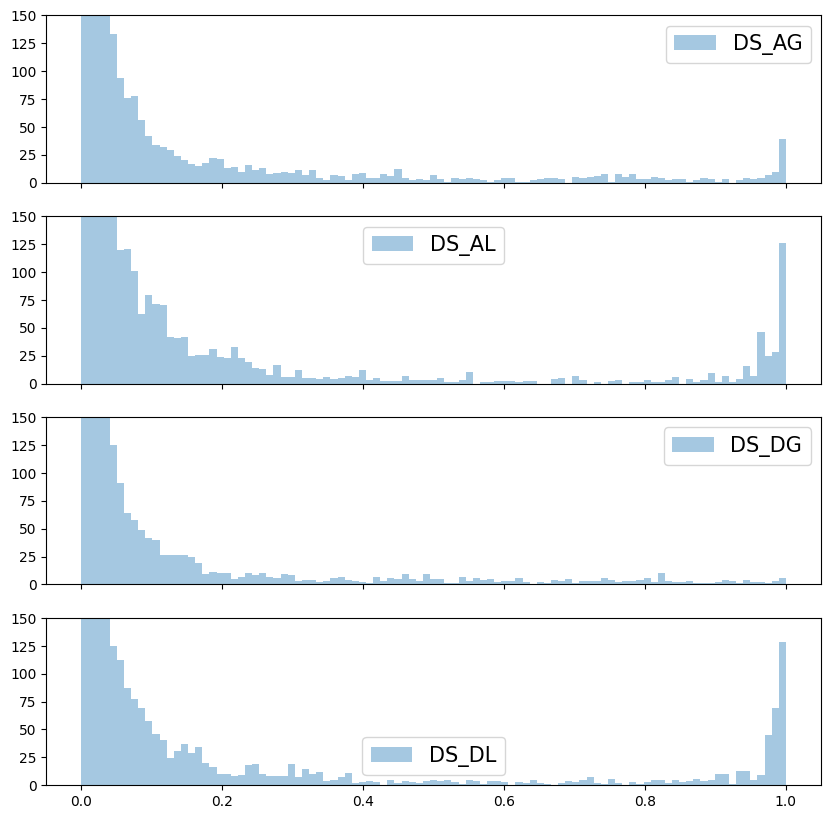

In [323]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(4,1,figsize=(10,10), sharex=True, sharey=True)
ax[0].hist(splice_ABE['DS_AG'], bins = np.linspace(0,1,100), label='DS_AG', alpha=.4);
ax[1].hist(splice_ABE['DS_AL'], bins = np.linspace(0,1,100), label='DS_AL', alpha=.4);
ax[2].hist(splice_ABE['DS_DG'], bins = np.linspace(0,1,100), label='DS_DG', alpha=.4);
ax[3].hist(splice_ABE['DS_DL'], bins = np.linspace(0,1,100), label='DS_DL', alpha=.4);

for i in range(4):
    ax[i].legend(fontsize=15)

ax[0].set_ylim(0,150)
#plt.yscale('log')

In [195]:
cutoff = 0.8
splice_ABE[(splice_ABE['DS_AG']>=cutoff) | (splice_ABE['DS_AL']>=cutoff) | (splice_ABE['DS_DG']>=cutoff) | (splice_ABE['DS_DL']>=cutoff)]

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,Gene,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
89,5,69235001,.,C,T,40,.,SpliceAI=T|CDK7|0.00|0.00|0.91|0.02|5|-7|-2|40,CDK7,0.00,0.00,0.91,0.02,5.0,-7.0,-2.0,40.0
110,5,69235008,.,T,G,40,.,SpliceAI=G|CDK7|0.00|0.00|0.91|0.01|-1|23|-1|33,CDK7,0.00,0.00,0.91,0.01,-1.0,23.0,-1.0,33.0
182,5,69235032,.,G,T,40,.,SpliceAI=T|CDK7|0.00|0.00|0.81|0.00|-2|-26|-2|-26,CDK7,0.00,0.00,0.81,0.00,-2.0,-26.0,-2.0,-26.0
185,5,69235033,.,G,T,40,.,SpliceAI=T|CDK7|0.00|0.00|0.82|0.01|-2|0|-2|8,CDK7,0.00,0.00,0.82,0.01,-2.0,0.0,-2.0,8.0
210,5,69235042,.,G,A,40,.,SpliceAI=A|CDK7|0.00|-0.00|0.03|1.00|-36|39|-3...,CDK7,0.00,0.00,0.03,1.00,-36.0,39.0,-36.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18056,6,110667576,.,T,A,40,.,SpliceAI=A|CDK19|0.81|1.00|0.00|0.00|-14|-2|-3...,CDK19,0.81,1.00,0.00,0.00,-14.0,-2.0,-33.0,-2.0
18057,6,110667575,.,C,T,40,.,SpliceAI=T|CDK19|0.50|0.99|0.00|0.00|-13|-1|-2|-1,CDK19,0.50,0.99,0.00,0.00,-13.0,-1.0,-2.0,-1.0
18058,6,110667575,.,C,A,40,.,SpliceAI=A|CDK19|0.74|0.99|0.00|0.00|-13|-1|-6|-1,CDK19,0.74,0.99,0.00,0.00,-13.0,-1.0,-6.0,-1.0
18074,6,110746203,.,T,G,40,.,SpliceAI=G|CDK19|0.55|1.00|0.00|0.00|-7|-2|-7|-2,CDK19,0.55,1.00,0.00,0.00,-7.0,-2.0,-7.0,-2.0


In [210]:
# combining with ABE editing data and assigning guides
ABE_edits = pd.read_csv('splicing/edits_ABE.csv')

for i, val in ABE_edits.iterrows():

    new = str(val['CHROM']) + str(val['POS']) + str(val['REF']) + str(val['ALT'])
    ABE_edits.loc[i, 'identifier'] = new

In [213]:
#and do the same for splice AI output for merging rows
for i, val in splice_ABE.iterrows():

    new = str(val['#CHROM']) + str(val['POS']) + str(val['REF']) + str(val['ALT'])
    splice_ABE.loc[i, 'identifier'] = new

In [219]:
sp_merge = pd.merge(ABE_edits, splice_ABE, on='identifier')
editing_ABE_orig = pd.read_csv('ABE_screen_data/ABE_editing/ABE_all_samples_combined_edit.zip')

In [247]:
j = ['+1G>T','+4A>G','+5A>G','+14G>T','']
j

['+1G>T', '+4A>G', '+5A>G', '+14G>T', '']

In [250]:
g = 'gRNA_CDK7_targ_17'
subset_sp = sp_merge[sp_merge['gRNA_id']==g]
subset_ABE = editing_ABE_orig[editing_ABE_orig['gRNA_id']==g].reset_index(drop=True)

subset_sp.loc[subset_sp['DNA_edit'].isin(['+5G>A', '+9T>A', '', 'asdf']), 'DS_DL']


1358    0.0
1499    0.0
Name: DS_DL, dtype: float64

In [244]:
subset_sp

,CHROM,POS_x,REF_x,ALT_x,DNA_edit,gRNA_id,identifier,#CHROM,POS_y,ID,...,INFO,Gene,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
1222,5,69235016,A,C,+1A>C,gRNA_CDK7_targ_17,569235016AC,5,69235016,.,...,SpliceAI=C|CDK7|0.00|0.00|0.00|0.00|26|2|25|-9,CDK7,0.0,0.0,0.00,0.00,26.0,2.0,25.0,-9.0
1234,5,69235016,A,G,+1A>G,gRNA_CDK7_targ_17,569235016AG,5,69235016,.,...,SpliceAI=G|CDK7|0.00|0.00|0.00|0.00|26|2|-10|25,CDK7,0.0,0.0,0.00,0.00,26.0,2.0,-10.0,25.0
1246,5,69235016,A,T,+1A>T,gRNA_CDK7_targ_17,569235016AT,5,69235016,.,...,SpliceAI=T|CDK7|0.00|0.00|0.00|0.00|26|2|-10|25,CDK7,0.0,0.0,0.00,0.00,26.0,2.0,-10.0,25.0
1258,5,69235017,G,A,+2G>A,gRNA_CDK7_targ_17,569235017GA,5,69235017,.,...,SpliceAI=A|CDK7|0.00|0.00|0.00|0.00|25|1|-11|24,CDK7,0.0,0.0,0.00,0.00,25.0,1.0,-11.0,24.0
1270,5,69235017,G,C,+2G>C,gRNA_CDK7_targ_17,569235017GC,5,69235017,.,...,SpliceAI=C|CDK7|0.00|0.00|0.00|0.00|25|1|-11|-10,CDK7,0.0,0.0,0.00,0.00,25.0,1.0,-11.0,-10.0
1282,5,69235017,G,T,+2G>T,gRNA_CDK7_targ_17,569235017GT,5,69235017,.,...,SpliceAI=T|CDK7|0.00|0.00|0.00|0.00|25|1|-11|24,CDK7,0.0,0.0,0.00,0.00,25.0,1.0,-11.0,24.0
1294,5,69235018,C,A,+3C>A,gRNA_CDK7_targ_17,569235018CA,5,69235018,.,...,SpliceAI=A|CDK7|0.00|0.00|0.00|0.00|0|24|23|-11,CDK7,0.0,0.0,0.00,0.00,0.0,24.0,23.0,-11.0
1306,5,69235018,C,G,+3C>G,gRNA_CDK7_targ_17,569235018CG,5,69235018,.,...,SpliceAI=G|CDK7|0.00|0.00|0.44|0.00|-1|3|-1|23,CDK7,0.0,0.0,0.44,0.00,-1.0,3.0,-1.0,23.0
1318,5,69235018,C,T,+3C>T,gRNA_CDK7_targ_17,569235018CT,5,69235018,.,...,SpliceAI=T|CDK7|0.00|0.00|0.00|0.00|-12|3|-2|23,CDK7,0.0,0.0,0.00,0.00,-12.0,3.0,-2.0,23.0
1329,5,69235019,T,A,+4T>A,gRNA_CDK7_targ_17,569235019TA,5,69235019,.,...,SpliceAI=A|CDK7|0.00|0.00|0.00|0.00|2|-14|-13|22,CDK7,0.0,0.0,0.00,0.00,2.0,-14.0,-13.0,22.0


In [251]:
guides = np.unique(editing_ABE_orig['gRNA_id'])

abe_holder = []
#for each edit, taking the MAXIMUM value for each DS 
for g in guides:
    subset_sp = sp_merge[sp_merge['gRNA_id']==g]
    subset_ABE = editing_ABE_orig[editing_ABE_orig['gRNA_id']==g].reset_index(drop=True)
    for i, val in subset_ABE.iterrows():
        dna_mods = val['DNA Change'].split(',')
        if dna_mods != ['No edit']:
            subset_ABE.loc[i, 'DS_AG'] = max(subset_sp.loc[subset_sp['DNA_edit'].isin(dna_mods), 'DS_AG'])
            subset_ABE.loc[i, 'DS_AL'] = max(subset_sp.loc[subset_sp['DNA_edit'].isin(dna_mods), 'DS_AL'])
            subset_ABE.loc[i, 'DS_DG'] = max(subset_sp.loc[subset_sp['DNA_edit'].isin(dna_mods), 'DS_DG'])
            subset_ABE.loc[i, 'DS_DL'] = max(subset_sp.loc[subset_sp['DNA_edit'].isin(dna_mods), 'DS_DL'])

    abe_holder.append(subset_ABE)


In [252]:
abe_splice_merge = pd.concat(abe_holder)


In [ ]:
#abe_splice_merge.to_csv('splicing/ABE_edit_spliceAI_merge.csv', index=False)

In [267]:
high_edit = abe_splice_merge[abe_splice_merge['%Reads']>=10]

cutoff = 0.8
l1 = high_edit[(high_edit['DS_AG']>=cutoff) | (high_edit['DS_AL']>=cutoff) | (high_edit['DS_DG']>=cutoff) | (high_edit['DS_DL']>=cutoff)]


# merging reads to get actual percentage for each DNA change

In [448]:
abe_splice_merge[abe_splice_merge['gRNA_id']=='gRNA_CDK19_targ_6273']

,Edit,HGVSp,Num_edits,DNA Change,Canonical_edit,Canonical_window,gRNA_id,#Reads,%Reads,DS_AG,DS_AL,DS_DG,DS_DL
0,TGGTCGGTGCCGGTGGGCCT,Y502H,20,"+6A>G,+9A>G,",True,False,gRNA_CDK19_targ_6273,201200,82.459354,0.0,0.0,0.00,0.08
1,TGGTCGGTACCGGTGGGCCT,WT,20,"+6A>G,",True,True,gRNA_CDK19_targ_6273,26130,10.709060,0.0,0.0,0.00,0.06
2,TGGTCAGTACCGGTGGGCCT,WT,20,No edit,True,True,gRNA_CDK19_targ_6273,6764,2.772143,NaN,NaN,NaN,NaN
3,TGGTTAGTACCGGTGGGCCT,WT,20,"+5C>T,",False,True,gRNA_CDK19_targ_6273,1385,0.567625,0.0,0.0,0.00,0.03
4,TGGTCAGTACCGGTGGGTCT,A499T,20,"+18C>T,",False,False,gRNA_CDK19_targ_6273,1029,0.421723,0.0,0.0,0.03,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,TTGTCGGTGCCGGGGGGCCT,H500P_Y502H,20,"+2G>T,+6A>G,+9A>G,+14T>G,",False,False,gRNA_CDK19_targ_6273,1,0.000410,0.0,0.0,0.00,0.08
336,TTGTCGGTGCCGGTAGGCCT,H500Y_Y502H,20,"+2G>T,+6A>G,+9A>G,+15G>A,",False,False,gRNA_CDK19_targ_6273,1,0.000410,0.0,0.0,0.02,0.08
337,TTGTCGGTGCCGTTGGGCCT,H500Q_Y502H,20,"+2G>T,+6A>G,+9A>G,+13G>T,",False,False,gRNA_CDK19_targ_6273,1,0.000410,0.0,0.0,0.13,0.08
338,TTGTCGTTGCCGGTGGGCCT,Y502Q,20,"+2G>T,+6A>G,+7G>T,+9A>G,",False,False,gRNA_CDK19_targ_6273,1,0.000410,0.0,0.0,0.33,0.08


In [502]:
#breaking it down by percentage for each SNP across different edit combinations

eh = []
for index1, guide in enumerate(list(np.unique(editing_ABE_orig['gRNA_id']))):
    subset = editing_ABE_orig[editing_ABE_orig['gRNA_id']==guide].reset_index(drop=True)

    holder = []
    for i, val in enumerate(list(subset['DNA Change'])):
        k = val.split(',')
        for j in k:
            if j not in ['']:
                holder.append(j)


    uniq_v = np.unique(holder)
    df_intermediate = pd.DataFrame(dict(zip(['DNA Change', '#Reads', '%Reads'], [uniq_v, np.zeros(len(uniq_v)), np.zeros(len(uniq_v))])))

    for idx, val2 in subset.iterrows():
        k = val2['DNA Change'].split(',')
        num_reads = val2['#Reads']
        perc_reads = val2['%Reads']
        for j in k:
            if j not in ['']:
                df_intermediate.loc[df_intermediate['DNA Change']==j, '#Reads'] += num_reads
                df_intermediate.loc[df_intermediate['DNA Change']==j, '%Reads'] += perc_reads


    df_intermediate['gRNA_id'] = guide
    eh.append(df_intermediate)

    if index1%100==0:
        print(index1)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400


In [506]:
ABE_single_read_perc = pd.concat(eh)

ABE_single_read_perc

,DNA Change,#Reads,%Reads,gRNA_id
0,+10C>A,324.0,0.132787,gRNA_CDK19_targ_6273
1,+10C>G,199.0,0.081558,gRNA_CDK19_targ_6273
2,+10C>T,30.0,0.012295,gRNA_CDK19_targ_6273
3,+11C>A,242.0,0.099181,gRNA_CDK19_targ_6273
4,+11C>G,113.0,0.046312,gRNA_CDK19_targ_6273
...,...,...,...,...
56,+8C>T,728.0,0.441841,gRNA_CDK9_targ_1739
57,+9G>A,148.0,0.089825,gRNA_CDK9_targ_1739
58,+9G>C,86.0,0.052196,gRNA_CDK9_targ_1739
59,+9G>T,150.0,0.091039,gRNA_CDK9_targ_1739


In [520]:
ABE_edits = pd.read_csv('splicing/edits_ABE.csv').rename(columns={'DNA_edit':'DNA Change'})
m_ABE_single = pd.merge(ABE_single_read_perc, ABE_edits, on=['gRNA_id', 'DNA Change'])
#NOTE THAT THIS REMOVES "NO EDIT"; Need to add back in afterward

for i, val in m_ABE_single.iterrows():

    new = str(int(val['CHROM'])) + str(int(val['POS'])) + str(val['REF']) + str(val['ALT'])
    m_ABE_single.loc[i, 'identifier'] = new

In [521]:
m_ABE_single

,DNA Change,#Reads,%Reads,gRNA_id,CHROM,POS,REF,ALT,identifier
0,+10C>A,324.0,0.132787,gRNA_CDK19_targ_6273,6,110614541,C,A,6110614541CA
1,+10C>G,199.0,0.081558,gRNA_CDK19_targ_6273,6,110614541,C,G,6110614541CG
2,+10C>T,30.0,0.012295,gRNA_CDK19_targ_6273,6,110614541,C,T,6110614541CT
3,+11C>A,242.0,0.099181,gRNA_CDK19_targ_6273,6,110614542,C,A,6110614542CA
4,+11C>G,113.0,0.046312,gRNA_CDK19_targ_6273,6,110614542,C,G,6110614542CG
...,...,...,...,...,...,...,...,...,...
143923,+8C>G,560.0,0.339878,gRNA_CDK9_targ_1739,9,127789535,G,C,9127789535GC
143924,+8C>T,728.0,0.441841,gRNA_CDK9_targ_1739,9,127789535,G,A,9127789535GA
143925,+9G>A,148.0,0.089825,gRNA_CDK9_targ_1739,9,127789534,C,T,9127789534CT
143926,+9G>C,86.0,0.052196,gRNA_CDK9_targ_1739,9,127789534,C,G,9127789534CG


In [ ]:
s2 = splice_ABE[['Gene','DS_AG', 'DS_AL', 'DS_DG', 'DS_DL', 'DP_AG', 'DP_AL', 'DP_DG', 'DP_DL','identifier']]
merged_FULL = pd.merge(m_ABE_single, s2, on='identifier', how='left')
merged_FULL

,DNA Change,#Reads,%Reads,gRNA_id,CHROM,POS,REF,ALT,identifier,Gene,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
0,+10C>A,324.0,0.132787,gRNA_CDK19_targ_6273,6,110614541,C,A,6110614541CA,CDK19,0.0,0.0,0.0,0.08,35.0,8.0,28.0,1.0
1,+10C>G,199.0,0.081558,gRNA_CDK19_targ_6273,6,110614541,C,G,6110614541CG,CDK19,0.0,0.0,0.0,0.08,35.0,1.0,-25.0,1.0
2,+10C>T,30.0,0.012295,gRNA_CDK19_targ_6273,6,110614541,C,T,6110614541CT,CDK19,0.0,0.0,0.0,0.08,35.0,1.0,-25.0,1.0
3,+11C>A,242.0,0.099181,gRNA_CDK19_targ_6273,6,110614542,C,A,6110614542CA,CDK19,0.0,0.0,0.0,0.08,34.0,7.0,27.0,0.0
4,+11C>G,113.0,0.046312,gRNA_CDK19_targ_6273,6,110614542,C,G,6110614542CG,CDK19,0.0,0.0,0.0,0.08,34.0,7.0,27.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143923,+8C>G,560.0,0.339878,gRNA_CDK9_targ_1739,9,127789535,G,C,9127789535GC,CDK9,0.0,0.0,0.0,0.00,-6.0,-5.0,-11.0,-5.0
143924,+8C>T,728.0,0.441841,gRNA_CDK9_targ_1739,9,127789535,G,A,9127789535GA,CDK9,0.0,0.0,0.0,0.00,29.0,-5.0,26.0,-5.0
143925,+9G>A,148.0,0.089825,gRNA_CDK9_targ_1739,9,127789534,C,T,9127789534CT,CDK9,0.0,0.0,0.0,0.00,-2.0,30.0,-2.0,29.0
143926,+9G>C,86.0,0.052196,gRNA_CDK9_targ_1739,9,127789534,C,G,9127789534CG,CDK9,0.0,0.0,0.0,0.00,0.0,30.0,0.0,31.0


In [ ]:
#adding back the NO EDIT information
no_edit = ABE_single_read_perc[ABE_single_read_perc['DNA Change']=='No edit'].reset_index(drop=True)

merged_full_FULL = pd.concat((merged_FULL, no_edit))

#merged_full_FULL.to_csv('splicing/ABE_single_edit_spliceAI_FULL.csv', index=False)

In [537]:
merged_full_FULL[merged_full_FULL['%Reads']>=90].sort_values(by='DS_DL', ascending=False)

,DNA Change,#Reads,%Reads,gRNA_id,CHROM,POS,REF,ALT,identifier,Gene,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
99431,+5A>G,220108.0,92.355074,gRNA_CDK8_targ_939,13.0,26400552.0,T,C,1326400552TC,CDK8,0.00,0.0,0.46,0.98,-2.0,-10.0,45.0,-2.0
99368,+4A>G,181209.0,91.988466,gRNA_CDK8_targ_938,13.0,26400552.0,T,C,1326400552TC,CDK8,0.00,0.0,0.46,0.98,-2.0,-10.0,45.0,-2.0
11289,+4A>G,61361.0,90.552366,gRNA_CDK19_targ_6465,6.0,110627000.0,A,G,6110627000AG,CDK19,0.00,0.0,0.00,0.98,2.0,21.0,-32.0,2.0
7823,+5A>G,252393.0,93.618623,gRNA_CDK19_targ_6407,6.0,110622813.0,A,G,6110622813AG,CDK19,0.02,0.0,0.76,0.91,-35.0,39.0,-2.0,2.0
71736,+6A>G,205505.0,91.034131,gRNA_CDK8_targ_473,13.0,26254766.0,A,G,1326254766AG,CDK8,0.00,0.0,0.99,0.36,9.0,-7.0,-1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,No edit,59296.0,94.304754,gRNA_CDK9_targ_1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2145,No edit,70423.0,96.088143,gRNA_CDK9_targ_1451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2192,No edit,356419.0,90.941542,gRNA_CDK9_targ_1498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2217,No edit,9966.0,90.394558,gRNA_CDK9_targ_1523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Processing CBE output

In [711]:
splice_CBE = pd.read_csv('splicing/output_CBE.vcf', header=30, sep='\t')


for i, val in splice_CBE.iterrows():
    a = val['INFO']
    s = a.split('|')

    splice_CBE.loc[i, 'Gene'] = s[1]
    splice_CBE.loc[i, 'DS_AG'] = np.sqrt(float(s[2])**2)
    splice_CBE.loc[i, 'DS_AL'] = np.sqrt(float(s[3])**2)
    splice_CBE.loc[i, 'DS_DG'] = np.sqrt(float(s[4])**2)
    splice_CBE.loc[i, 'DS_DL'] = np.sqrt(float(s[5])**2)
    splice_CBE.loc[i, 'DP_AG'] = float(s[6])
    splice_CBE.loc[i, 'DP_AL'] = float(s[7])
    splice_CBE.loc[i, 'DP_DG'] = float(s[8])
    splice_CBE.loc[i, 'DP_DL'] = float(s[9])

In [713]:
editing_CBE_orig = pd.read_csv('CBE_editing/all_samples_combined_edit.zip')

In [715]:
#breaking it down by percentage for each SNP across different edit combinations
eh = []
for index1, guide in enumerate(list(np.unique(editing_CBE_orig['gRNA_id']))):
    subset = editing_CBE_orig[editing_CBE_orig['gRNA_id']==guide].reset_index(drop=True)

    holder = []
    for i, val in enumerate(list(subset['DNA Change'])):
        k = val.split(',')
        for j in k:
            if j not in ['']:
                holder.append(j)


    uniq_v = np.unique(holder)
    df_intermediate = pd.DataFrame(dict(zip(['DNA Change', '#Reads', '%Reads'], [uniq_v, np.zeros(len(uniq_v)), np.zeros(len(uniq_v))])))

    for idx, val2 in subset.iterrows():
        k = val2['DNA Change'].split(',')
        num_reads = val2['#Reads']
        perc_reads = val2['%Reads']
        for j in k:
            if j not in ['']:
                df_intermediate.loc[df_intermediate['DNA Change']==j, '#Reads'] += num_reads
                df_intermediate.loc[df_intermediate['DNA Change']==j, '%Reads'] += perc_reads


    df_intermediate['gRNA_id'] = guide
    eh.append(df_intermediate)

    if index1%100==0:
        print(index1)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400


In [716]:
CBE_single_read_perc = pd.concat(eh)

In [717]:
CBE_edits = pd.read_csv('splicing/edits_CBE.csv').rename(columns={'DNA_edit':'DNA Change'})
m_CBE_single = pd.merge(CBE_single_read_perc, CBE_edits, on=['gRNA_id', 'DNA Change'])
#NOTE THAT THIS REMOVES "NO EDIT"; Need to add back in afterward

for i, val in m_CBE_single.iterrows():

    new = str(int(val['CHROM'])) + str(int(val['POS'])) + str(val['REF']) + str(val['ALT'])
    m_CBE_single.loc[i, 'identifier'] = new

In [719]:
#and do the same for splice AI output for merging rows
for i, val in splice_CBE.iterrows():

    new = str(val['#CHROM']) + str(val['POS']) + str(val['REF']) + str(val['ALT'])
    splice_CBE.loc[i, 'identifier'] = new

In [720]:
s2 = splice_CBE[['Gene','DS_AG', 'DS_AL', 'DS_DG', 'DS_DL', 'DP_AG', 'DP_AL', 'DP_DG', 'DP_DL','identifier']]
merged_FULL = pd.merge(m_CBE_single, s2, on='identifier', how='left')

#adding back the NO EDIT information
no_edit = CBE_single_read_perc[CBE_single_read_perc['DNA Change']=='No edit'].reset_index(drop=True)

merged_full_FULL = pd.concat((merged_FULL, no_edit))

In [723]:
CBE_edits

,CHROM,POS,REF,ALT,DNA Change,gRNA_id
0,5,69234981,T,A,+10T>A,gRNA_CDK7_targ_1
1,5,69234981,T,C,+10T>C,gRNA_CDK7_targ_1
2,5,69234981,T,G,+10T>G,gRNA_CDK7_targ_1
3,5,69234982,C,A,+11C>A,gRNA_CDK7_targ_1
4,5,69234982,C,G,+11C>G,gRNA_CDK7_targ_1
...,...,...,...,...,...,...
144529,6,110815133,C,G,+8G>C,gRNA_CDK19_targ_6972
144530,6,110815133,C,A,+8G>T,gRNA_CDK19_targ_6972
144531,6,110815132,T,G,+9A>C,gRNA_CDK19_targ_6972
144532,6,110815132,T,C,+9A>G,gRNA_CDK19_targ_6972


In [ ]:
#merged_full_FULL.to_csv('CBE_single_edit_spliceAI_FULL.csv', index=False)

# highlight the guides that popup on the tiling map as a sanity check (they should be near exon junctions)

In [281]:
#highlight the guide
import gffutils
import seaborn as sns
#GRCh38 database
#loading in genome annotations

#HUMAN
db = gffutils.FeatureDB('/Users/samgould/Desktop/FSR Lab/reference files/gencode_v44_GRCh38.db', keep_order=True)
#MOUSE
#db = gffutils.FeatureDB('/Users/samgould/Desktop/FSR Lab/reference files/gencode_vm33_GRCm39.db', keep_order=True)

#accessed genome annotations using gffutils package
#canonical MANE transcript for CDK9 (CDK9-201)
tx = 'ENST00000373264.5'


def tx_processor(tx):
    cds = list(db.children(tx, order_by='+end', featuretype=['CDS']))
    start_end_cds = [[i.start, i.end] for i in cds]
    strand = db[tx].strand
    chrom = db[tx].chrom
    #print(chrom[3:])
    #print(strand)
    #print(db[tx].attributes)

    #including 20 nt buffer on either side of exon for generating PAM sequences
    start_end_cds_20 = []
    buffer = 20
    for k in start_end_cds:
        h = []
        for idx, j in enumerate(k):
            if idx==0:
                h.append(j-buffer)
            if idx==1:
                h.append(j+buffer)
        start_end_cds_20.append(h)

    return start_end_cds_20, start_end_cds, chrom, strand

In [271]:
def proto_viz(proto_df):
    abs_max = max(max(proto_df['end']), max(proto_df['start'])) - (min(proto_df['start'])-20)

    c = np.zeros(int(abs_max))

    plus = [c.copy()]
    minus = [c.copy()]

    for i, val in proto_df.iterrows():
        s = int(val['start']  - (min(proto_df['start'])-20))
        e = int(val['end']- (min(proto_df['start'])-20))
        strand = val['strand']

        num_pegs = 1

        if strand=='+':
            num_rows = len(plus)
            sum1 = []
            for i in range(num_rows):
                sum1.append(sum(plus[i][s:e]))

            open = []
            for k, val2 in enumerate(sum1):
                if val2==0:
                    open.append(k)
                else:
                    continue

            if len(open)==0: #add a new row
                newrow = c.copy()
                newrow[s:e]+=num_pegs
                plus.append(newrow)

            else: #otherwise, add to lowest existing row
                row_to_add = min(open)
                plus[row_to_add][s:e]+=num_pegs


        else: #minus
            s = int(val['end']- (min(proto_df['start'])-20))
            e = int(val['start']- (min(proto_df['start'])-20))

            num_rows = len(minus)
            sum1 = []
            for i in range(num_rows):
                sum1.append(sum(minus[i][s:e]))

            open = []
            for k, val2 in enumerate(sum1):
                if val2==0:
                    open.append(k)
                else:
                    continue

            if len(open)==0: #add a new row
                newrow = c.copy()
                newrow[s:e]+=num_pegs
                minus.append(newrow)

            else: #otherwise, add to lowest existing row
                row_to_add = min(open)
                minus[row_to_add][s:e]+=num_pegs


    #make them the same size
    for i in range(len(plus)-len(minus)):
        minus.append(c.copy())

    return plus, minus

In [273]:
library = pd.read_csv('CDK_library_final.csv')

In [278]:
merged = pd.read_csv('CDK_library_final.csv')
df = pd.read_csv('cdks_info_updated.csv')

gene = 'CDK9'


guides = merged[(merged['Gene']==gene) & (merged['classification']=='targeting')].copy()

proto_df = guides.rename(columns = {'proto_start':'start', 'proto_end':'end'})
plus, minus = proto_viz(proto_df)

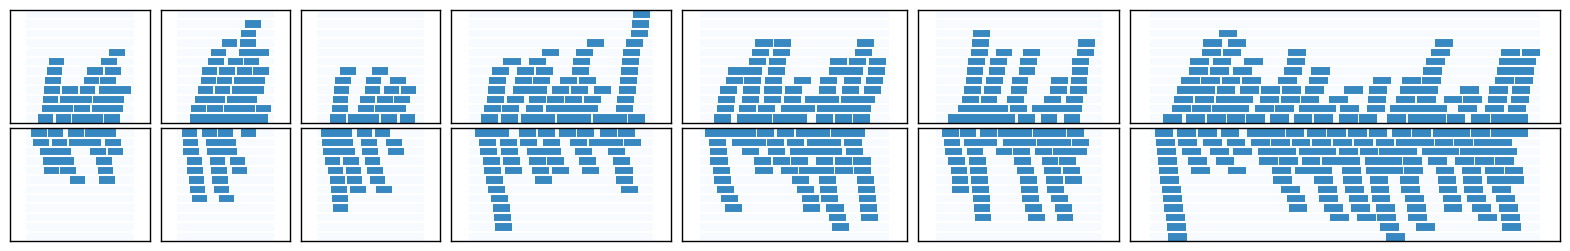

In [282]:
tx = df.loc[df['Gene']==gene, 'Transcript ID'].values[0]
protein = df.loc[df['Gene']==gene, 'Protein'].values[0]

#--------check that it's the correct transcript and get the WT transcript sequence-------
start_end_cds_20, start_end_cds, chrom, strand = tx_processor(tx)

bounds = np.asarray(start_end_cds)- (min(proto_df['start'])-20)
bounds[:,1] =bounds[:,1]+20
bounds[:,0] =bounds[:,0]-20

wr = [i[1]-i[0] for i in bounds]
wr = [i/max(wr) for i in wr]

#plus, minus = proto_viz('num_pegRNAs')

#max_pegs = max(proto_df['num_pegRNAs'])
max_pegs = 1.5

fig, ax = plt.subplots(2,len(bounds), figsize=(20,3), width_ratios = wr)
#cbar_ax = fig.add_axes([.91, .3, .03, .4])

for i, val in enumerate(bounds):

    p = np.asarray(plus)[:,max(0,int(val[0])):int(val[1])][::-1]
    g = sns.heatmap(p, cmap='Blues', ax=ax[0][i], vmax = max_pegs, yticklabels=False, xticklabels=False, cbar=False)
    ax[0][i].hlines(list(range(len(p)))[1:], *ax[0][i].get_xlim(), color='white')
    ax[0][i].set_xlim(-20, len(p[0]) + 20)


    m = np.asarray(minus)[:,max(0,int(val[0])):int(val[1])]
    g2 = sns.heatmap(m, cmap='Blues', ax=ax[1][i], vmax=max_pegs, cbar=False, yticklabels=False,xticklabels=False, cbar_ax=None)
    ax[1][i].set_xlim(-20, len(p[0]) + 20)

    ax[1][i].hlines(list(range(len(m)))[1:], *ax[1][i].get_xlim(), color='white')

    for _, spine in g.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)
    for _, spine in g2.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)

#ax[0][5].set_title('Number of pegRNAs per protospacer', fontsize=15)
plt.subplots_adjust(wspace=.05, hspace=.05)

In [294]:
def proto_viz_v2(proto_df, guides_to_highlight):
    abs_max = max(max(proto_df['end']), max(proto_df['start'])) - (min(proto_df['start'])-20)

    c = np.zeros(int(abs_max))

    plus = [c.copy()]
    minus = [c.copy()]

    for i, val in proto_df.iterrows():
        s = int(val['start']  - (min(proto_df['start'])-20))
        e = int(val['end']- (min(proto_df['start'])-20))
        strand = val['strand']

        if val['gRNA_id'] in guides_to_highlight:
            num_pegs = 1
        else:
            num_pegs = -1

        if strand=='+':
            num_rows = len(plus)
            sum1 = []
            for i in range(num_rows):
                sum1.append(sum(plus[i][s:e]))

            open = []
            for k, val2 in enumerate(sum1):
                if val2==0:
                    open.append(k)
                else:
                    continue

            if len(open)==0: #add a new row
                newrow = c.copy()
                newrow[s:e]+=num_pegs
                plus.append(newrow)

            else: #otherwise, add to lowest existing row
                row_to_add = min(open)
                plus[row_to_add][s:e]+=num_pegs


        else: #minus
            s = int(val['end']- (min(proto_df['start'])-20))
            e = int(val['start']- (min(proto_df['start'])-20))

            num_rows = len(minus)
            sum1 = []
            for i in range(num_rows):
                sum1.append(sum(minus[i][s:e]))

            open = []
            for k, val2 in enumerate(sum1):
                if val2==0:
                    open.append(k)
                else:
                    continue

            if len(open)==0: #add a new row
                newrow = c.copy()
                newrow[s:e]+=num_pegs
                minus.append(newrow)

            else: #otherwise, add to lowest existing row
                row_to_add = min(open)
                minus[row_to_add][s:e]+=num_pegs


    #make them the same size
    for i in range(len(plus)-len(minus)):
        minus.append(c.copy())

    return plus, minus

In [734]:
merged = pd.read_csv('CDK_library_final.csv')
df = pd.read_csv('cdks_info_updated.csv')

gene = 'CDK7'
guides = merged[(merged['Gene']==gene) & (merged['classification']=='targeting')].copy()

proto_df = guides.rename(columns = {'proto_start':'start', 'proto_end':'end'})

#abe_splice_full = pd.read_csv('splicing/ABE_single_edit_spliceAI_FULL.csv')
cbe_splice_full = pd.read_csv('splicing/CBE_single_edit_spliceAI_FULL.csv')
#selecting guides to highlight
edit_cutoff = 20
#high_edit = abe_splice_full[abe_splice_full['%Reads']>=edit_cutoff]
high_edit = cbe_splice_full[cbe_splice_full['%Reads']>=edit_cutoff]

cutoff = 0.2
#l1 = high_edit[(high_edit['DS_AG']>=cutoff) | (high_edit['DS_AL']>=cutoff) | (high_edit['DS_DG']>=cutoff) | (high_edit['DS_DL']>=cutoff)]
metric = 'DS_DL'
l1 = high_edit[(high_edit[metric]>=cutoff)]

l1['Gene'] = [i.split('_')[1] for i in l1['gRNA_id']]
CDK9_high = np.unique(l1[l1['Gene']==gene]['gRNA_id'])

plus, minus = proto_viz_v2(proto_df, CDK9_high)

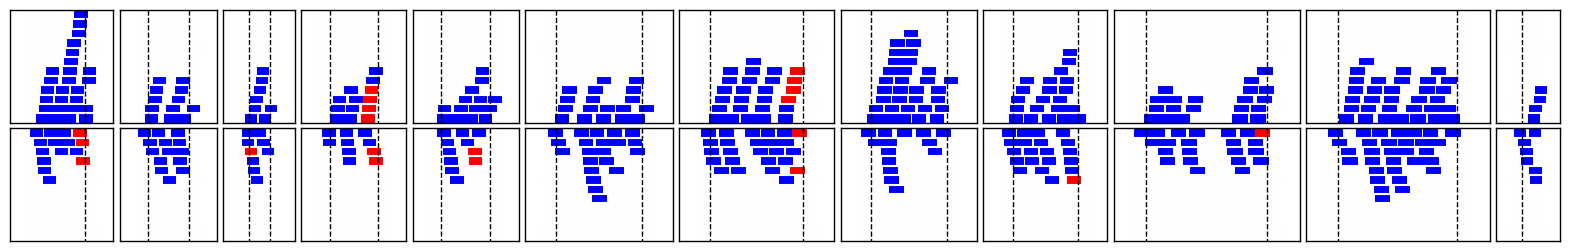

In [735]:
tx = df.loc[df['Gene']==gene, 'Transcript ID'].values[0]
protein = df.loc[df['Gene']==gene, 'Protein'].values[0]

#--------check that it's the correct transcript and get the WT transcript sequence-------
start_end_cds_20, start_end_cds, chrom, strand = tx_processor(tx)

#adding in exon annotations
exons = list(db.children(tx, order_by='+end', featuretype=['exon']))
exon_locs = [[i.start, i.end] for i in exons]
exon_locs_true = np.asarray(exon_locs)- (min(proto_df['start'])-20)

bounds = np.asarray(start_end_cds)- (min(proto_df['start'])-20)
bounds[:,1] =bounds[:,1]+20
bounds[:,0] =bounds[:,0]-20

wr = [i[1]-i[0] for i in bounds]
wr = [i/max(wr) for i in wr]

#plus, minus = proto_viz('num_pegRNAs')

#max_pegs = max(proto_df['num_pegRNAs'])
max_pegs = 1.5

fig, ax = plt.subplots(2,len(bounds), figsize=(20,3), width_ratios = wr)
#cbar_ax = fig.add_axes([.91, .3, .03, .4])

for i, val in enumerate(bounds):

    p = np.asarray(plus)[:,max(0,int(val[0])):int(val[1])][::-1]
    g = sns.heatmap(p, cmap='bwr', ax=ax[0][i], vmin=-1, vmax = 1, yticklabels=False, xticklabels=False, cbar=False)
    ax[0][i].hlines(list(range(len(p)))[1:], *ax[0][i].get_xlim(), color='white')
    ax[0][i].set_xlim(-20, len(p[0]) + 20)


    m = np.asarray(minus)[:,max(0,int(val[0])):int(val[1])]
    g2 = sns.heatmap(m, cmap='bwr', ax=ax[1][i], vmin=-1, vmax = 1, cbar=False, yticklabels=False,xticklabels=False, cbar_ax=None)
    ax[1][i].set_xlim(-20, len(p[0]) + 20)

    ax[1][i].hlines(list(range(len(m)))[1:], *ax[1][i].get_xlim(), color='white')

    #adding in the exon/intron junction lines
    ax[0][i].vlines(exon_locs_true[i][0]-max(0,int(val[0])), ymin=0, ymax = len(p), linestyle='dashed', color='black', linewidth=1)
    ax[0][i].vlines(exon_locs_true[i][1]-max(0,int(val[0])), ymin=0, ymax = len(p), linestyle='dashed', color='black', linewidth=1)
    ax[1][i].vlines(exon_locs_true[i][0]-max(0,int(val[0])), ymin=0, ymax = len(m), linestyle='dashed', color='black', linewidth=1)
    ax[1][i].vlines(exon_locs_true[i][1]-max(0,int(val[0])), ymin=0, ymax = len(m), linestyle='dashed', color='black', linewidth=1)

    for _, spine in g.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)
    for _, spine in g2.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)

#ax[0][5].set_title('Number of pegRNAs per protospacer', fontsize=15)

plt.subplots_adjust(wspace=.05, hspace=.05)

#fig.savefig(f'figures/{gene}_spliceAI_{metric}_greater_eq_{cutoff}_min_edit_{edit_cutoff}.png', dpi=400)

In [605]:
bounds

array([[   6.,  137.],
       [ 558.,  679.],
       [1375., 1505.],
       [1804., 2010.],
       [2071., 2282.],
       [2401., 2589.],
       [3035., 3437.]])

In [606]:
exon_locs_true

array([[ -89.,  117.],
       [ 578.,  659.],
       [1395., 1485.],
       [1824., 1990.],
       [2091., 2262.],
       [2421., 2569.],
       [3055., 4669.]])

In [592]:
list(range(len(p)))[1:]

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

# ADD indications of exon/intron junctions!

# Analysis in context of ABE and CBE T0 and DMSO conditions (vs. plasmid)

In [325]:
# analysis
targ_ABE = pd.read_csv('splicing/T0_DMSO_v_plasmid_ABE.csv')
targ_ABE

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
0,gRNA_CDK7_targ_1,CDK7,0.324563,-0.046902,-0.166163,0.037166,-0.046902,645.734931,0.211017,0.912590,...,0.692046,0.603300,1.000000,0.999986,0.603300,0.999986,20.076011,M1V,71.588676,1.0
1,gRNA_CDK7_targ_2,CDK7,-0.270123,-0.751858,-0.375490,-0.465824,-0.375490,557.858423,0.798340,0.424337,...,0.610531,0.586441,1.000000,0.999986,0.586441,0.999986,41.267755,D4G,37.749350,4.0
2,gRNA_CDK7_targ_3,CDK7,-0.105006,-0.499497,-0.299457,-0.301320,-0.299457,233.563698,0.643950,0.621769,...,0.567727,0.596702,1.000000,0.999986,0.567727,0.999986,18.482137,D4G,57.176816,4.0
3,gRNA_CDK7_targ_4,CDK7,0.338308,0.149534,0.296729,0.261523,0.296729,461.631780,0.064680,0.988318,...,0.487893,0.543749,0.945313,0.999986,0.487893,0.945313,35.818056,D4G,45.623508,4.0
4,gRNA_CDK7_targ_5,CDK7,1.071146,1.051349,0.870974,0.997823,1.051349,141.472107,0.000035,0.999999,...,0.000088,0.999980,0.030050,0.999986,0.000088,0.030050,3.036689,D4G_K6E,37.895878,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2725,gRNA_nt_8935,NT,-1.417849,-1.074326,-0.857324,-1.116500,-1.074326,510.185285,0.991822,0.044623,...,0.972022,0.106470,1.000000,0.850029,0.106470,0.850029,0.000000,0,0.000000,0.0
2726,gRNA_nt_8936,NT,-0.932215,0.127038,0.042110,-0.254356,0.042110,227.534527,0.406282,0.582841,...,0.569583,0.460075,1.000000,0.999986,0.460075,0.999986,0.000000,0,0.000000,0.0
2727,gRNA_nt_8937,NT,-0.243898,-0.273314,-0.399093,-0.305435,-0.273314,440.609714,0.675316,0.631575,...,0.020357,0.930421,0.197776,0.999986,0.020357,0.197776,0.000000,0,0.000000,0.0
2728,gRNA_nt_8938,NT,-0.392129,-0.586667,-0.777884,-0.585560,-0.586667,250.344003,0.885388,0.314385,...,0.380915,0.775637,0.847016,0.999986,0.380915,0.847016,0.000000,0,0.000000,0.0


In [684]:
targ_CBE = pd.read_csv('splicing/T0_DMSO_v_plasmid_CBE.csv')

ter = []
for i, val in targ_CBE.iterrows():
    if '*' in val['Top_HGVSp']:
        ter.append(val['gRNA_id'])

<Axes: xlabel='Gene', ylabel='LFC_median_T0'>

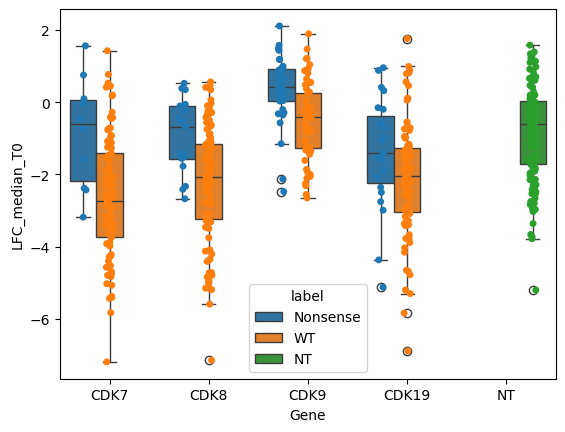

In [701]:
aa = targ_CBE[(targ_CBE['gRNA_id'].isin(ter)) & (targ_CBE['Top_HGVSp_%']>=50)]
bb = targ_CBE[(targ_CBE['WT_perc']>=90)]
dd = targ_CBE[targ_CBE['Gene']=='NT']
dd['label'] = 'NT'
bb['label']='WT'
aa['label'] = 'Nonsense'
cc = pd.concat((aa,bb,dd))
sns.boxplot(data=cc, x='Gene', y='LFC_median_T0', hue='label')
sns.stripplot(data=cc, x='Gene', y='LFC_median_T0',  hue='label', dodge=True, legend=False)

In [693]:
bb = targ_CBE[(targ_CBE['WT_perc']>=99)]
bb

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
37,gRNA_CDK7_targ_38,CDK7,-1.974836,-3.485087,-2.947977,-2.802633,-2.947977,193.600429,0.966841,0.118996,...,0.941766,0.099485,0.999999,1.000000,0.099485,0.999999,99.776894,K41N,0.163464,41.0
45,gRNA_CDK7_targ_46,CDK7,-1.703232,-2.879441,-2.835247,-2.472640,-2.835247,296.283088,0.939594,0.190906,...,0.927288,0.193970,0.999999,1.000000,0.193970,0.999999,99.277930,D53Y,0.262325,53.0
58,gRNA_CDK7_targ_59,CDK7,-0.714668,-1.309649,-0.517169,-0.847162,-0.714668,223.639575,0.529126,0.748566,...,0.241366,0.720039,0.582341,1.000000,0.241366,0.582341,99.240756,G76V,0.195015,76.0
72,gRNA_CDK7_targ_73,CDK7,-2.677478,-4.526777,-3.131302,-3.445185,-3.131302,238.152271,0.989686,0.047160,...,0.894415,0.173409,0.999999,1.000000,0.173409,0.999999,99.409633,E99*,0.241582,99.0
90,gRNA_CDK7_targ_91,CDK7,-6.720028,-4.679956,-3.403663,-4.934549,-4.679956,70.802748,0.998987,0.003997,...,0.958906,0.043354,0.999999,1.000000,0.043354,0.999999,99.350781,R136M,0.243457,136.0
148,gRNA_CDK7_targ_149,CDK7,-4.921682,-4.398156,-4.182974,-4.500937,-4.398156,190.959332,0.999108,0.009302,...,0.946657,0.111492,0.999999,1.000000,0.111492,0.999999,99.153820,R209M,0.259143,209.0
224,gRNA_CDK7_targ_225,CDK7,-5.023097,-7.080468,-3.498014,-5.200527,-5.023097,165.348692,0.999259,0.002738,...,0.980753,0.013824,0.999999,0.857697,0.013824,0.857697,99.635310,F346L,0.074892,346.0
225,gRNA_CDK7_targ_226,CDK7,-5.982886,-4.793085,-3.021969,-4.599313,-4.793085,167.883079,0.997912,0.008819,...,0.981054,0.036560,0.999999,1.000000,0.036560,0.999999,99.698399,I345N,0.102673,345.0
255,gRNA_CDK7_targ_256,CDK7,-1.921181,-3.090435,-2.188901,-2.400172,-2.188901,299.057574,0.937269,0.204008,...,0.507262,0.385498,0.831228,1.000000,0.385498,0.831228,99.485770,L45I,0.168455,45.0
256,gRNA_CDK7_targ_257,CDK7,-3.198013,-3.635211,-2.805938,-3.213054,-3.198013,204.271529,0.987543,0.069215,...,0.043649,0.550808,0.209915,1.000000,0.043649,0.209915,99.411583,L45I,0.165170,45.0


In [539]:
abe_splice = pd.read_csv('splicing/ABE_single_edit_spliceAI_FULL.csv')
abe_splice

,DNA Change,#Reads,%Reads,gRNA_id,CHROM,POS,REF,ALT,identifier,Gene,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
0,+10C>A,324.0,0.132787,gRNA_CDK19_targ_6273,6.0,110614541.0,C,A,6110614541CA,CDK19,0.0,0.0,0.0,0.08,35.0,8.0,28.0,1.0
1,+10C>G,199.0,0.081558,gRNA_CDK19_targ_6273,6.0,110614541.0,C,G,6110614541CG,CDK19,0.0,0.0,0.0,0.08,35.0,1.0,-25.0,1.0
2,+10C>T,30.0,0.012295,gRNA_CDK19_targ_6273,6.0,110614541.0,C,T,6110614541CT,CDK19,0.0,0.0,0.0,0.08,35.0,1.0,-25.0,1.0
3,+11C>A,242.0,0.099181,gRNA_CDK19_targ_6273,6.0,110614542.0,C,A,6110614542CA,CDK19,0.0,0.0,0.0,0.08,34.0,7.0,27.0,0.0
4,+11C>G,113.0,0.046312,gRNA_CDK19_targ_6273,6.0,110614542.0,C,G,6110614542CG,CDK19,0.0,0.0,0.0,0.08,34.0,7.0,27.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146356,No edit,9387.0,3.951922,gRNA_CDK9_targ_1735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146357,No edit,158.0,0.115970,gRNA_CDK9_targ_1736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146358,No edit,74.0,0.034685,gRNA_CDK9_targ_1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146359,No edit,310.0,0.111739,gRNA_CDK9_targ_1738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [705]:
#selecting guides to highlight
high_edit = abe_splice[abe_splice['%Reads']>=40]

cutoff = 0.8

#l1 = high_edit[(high_edit['DS_AG']>=cutoff) | (high_edit['DS_AL']>=cutoff) | (high_edit['DS_DG']>=cutoff) | (high_edit['DS_DL']>=cutoff)]

#l1 = high_edit[(high_edit['DS_AL']>=cutoff) | (high_edit['DS_DL']>=cutoff)]
l1 = high_edit[high_edit['DS_DL']>=cutoff]

l1['Gene'] = [i.split('_')[1] for i in l1['gRNA_id']]
#CDK9_high = np.unique(l1[l1['Gene']==gene]['gRNA_id'])

CDK9_high = np.unique(l1['gRNA_id'])

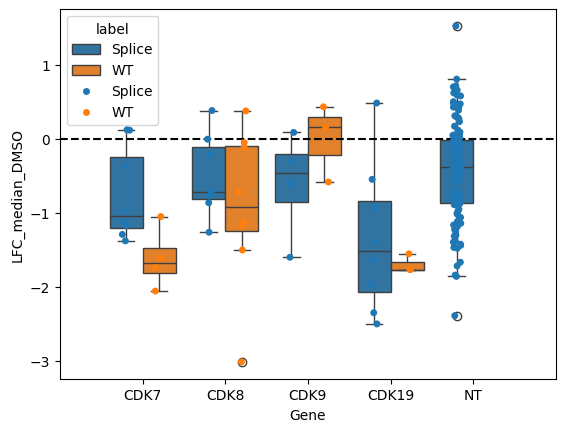

In [706]:
comp = targ_ABE[(targ_ABE['Gene']=='NT') | (targ_ABE['gRNA_id'].isin(CDK9_high))]
bb = targ_ABE[(targ_ABE['WT_perc']>=99)]
bb['label'] = 'WT'
comp['label'] = 'Splice'
comparison = pd.concat((comp, bb))
sns.boxplot(data=comparison, x='Gene', y='LFC_median_DMSO', hue='label')
sns.stripplot(data=comparison, x='Gene', y='LFC_median_DMSO', hue='label', dodge=True)
plt.hlines(0, xmin=-1, xmax=5, linestyle='dashed', color='black')
plt.xlim(-1,5)
fig.tight_layout()

In [710]:
abe_splice[(abe_splice['gRNA_id'].isin(list(bb['gRNA_id']))) & (abe_splice['%Reads']>=10)]

,DNA Change,#Reads,%Reads,gRNA_id,CHROM,POS,REF,ALT,identifier,Gene,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
7771,+7A>G,4341.0,12.766896,gRNA_CDK19_targ_6406,6.0,110622169.0,A,G,6110622169AG,CDK19,0.00,0.01,0.00,0.00,-3.0,-22.0,4.0,-3.0
14868,+7A>G,13701.0,53.666275,gRNA_CDK19_targ_6525,6.0,110638709.0,A,G,6110638709AG,CDK19,0.02,0.00,0.00,0.00,-3.0,-13.0,-20.0,28.0
65406,+7A>G,7503.0,67.949647,gRNA_CDK7_targ_91,5.0,69258156.0,A,G,569258156AG,CDK7,0.00,0.00,0.04,0.00,-3.0,-40.0,2.0,-3.0
71863,+8A>G,604845.0,78.619299,gRNA_CDK8_targ_475,13.0,26254773.0,A,G,1326254773AG,CDK8,0.00,0.00,0.04,0.59,-4.0,2.0,0.0,-4.0
74421,+9A>G,219529.0,66.430936,gRNA_CDK8_targ_518,13.0,26349185.0,A,G,1326349185AG,CDK8,0.00,0.00,0.07,0.36,-3.0,-45.0,-42.0,-3.0
74478,+8A>G,98998.0,81.678149,gRNA_CDK8_targ_519,13.0,26349185.0,A,G,1326349185AG,CDK8,0.00,0.00,0.07,0.36,-3.0,-45.0,-42.0,-3.0
77475,+14A>G,3839.0,10.325722,gRNA_CDK8_targ_570,13.0,26382879.0,A,G,1326382879AG,CDK8,0.00,0.00,0.00,0.02,-8.0,-34.0,-1.0,-8.0
77481,+16A>G,4652.0,12.512440,gRNA_CDK8_targ_570,13.0,26382881.0,A,G,1326382881AG,CDK8,0.00,0.00,0.00,0.04,-10.0,-48.0,-6.0,-10.0
77517,+9A>G,12565.0,33.795960,gRNA_CDK8_targ_570,13.0,26382874.0,A,G,1326382874AG,CDK8,0.00,0.00,0.00,0.84,25.0,-41.0,-1.0,-3.0
82062,+11A>G,30164.0,11.964049,gRNA_CDK8_targ_648,13.0,26397232.0,A,G,1326397232AG,CDK8,0.00,0.00,0.00,0.00,-1.0,-26.0,-1.0,-7.0


In [576]:
#put into bins!
#selecting guides to highlight
gene = 'CDK7'
high_edit = abe_splice[abe_splice['%Reads']>=5]

cutoff = 0.2

#l1 = high_edit[(high_edit['DS_AG']>=cutoff) | (high_edit['DS_AL']>=cutoff) | (high_edit['DS_DG']>=cutoff) | (high_edit['DS_DL']>=cutoff)]
bins = [[0.2,0.5], [0.5,0.8], [0.8,1]]

l1 = high_edit[(high_edit['DS_DL']>=cutoff)]
bh = []
for i, val in l1.iterrows():
    v = val['DS_DL']
    if (v>= bins[0][0]) & (v<bins[0][1]):
        bin1 = "∆0.2-0.5"
    elif (v>= bins[1][0]) & (v<bins[1][1]):
        bin1 = "∆0.5-0.8"
    elif (v>= bins[2][0]) & (v<=bins[2][1]):
        bin1 = "∆0.8-1.0"
    bh.append(bin1)

l1['bin'] = bh

l1['Gene'] = [i.split('_')[1] for i in l1['gRNA_id']]

CDK9_high = np.unique(l1['gRNA_id'])

m1 = pd.merge(l1, targ_ABE[targ_ABE['gRNA_id'].isin(CDK9_high)], on='gRNA_id')

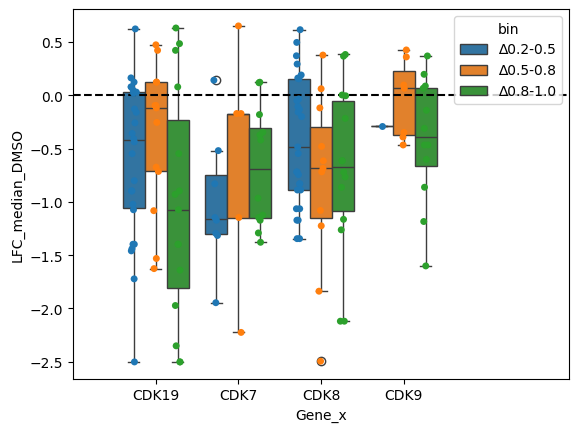

In [577]:
sns.boxplot(data=m1, x='Gene_x', y='LFC_median_DMSO', hue='bin', hue_order=["∆0.2-0.5", "∆0.5-0.8", "∆0.8-1.0"])
sns.stripplot(data=m1, x='Gene_x', y='LFC_median_DMSO', hue='bin', dodge=True, legend=False, hue_order=["∆0.2-0.5", "∆0.5-0.8", "∆0.8-1.0"])
plt.hlines(0, xmin=-1, xmax=5, linestyle='dashed', color='black')
plt.xlim(-1,5)
fig.tight_layout()

In [424]:
#selecting guides to highlight
gene = 'CDK7'
high_edit = abe_splice_merge[abe_splice_merge['%Reads']>=20]

cutoff = 0.2

#l1 = high_edit[(high_edit['DS_AG']>=cutoff) | (high_edit['DS_AL']>=cutoff) | (high_edit['DS_DG']>=cutoff) | (high_edit['DS_DL']>=cutoff)]

l1 = high_edit[(high_edit['DS_AL']>=cutoff) | (high_edit['DS_DL']>=cutoff)]
#l1 = high_edit[high_edit['DS_DL']>=cutoff]

l1['Gene'] = [i.split('_')[1] for i in l1['gRNA_id']]
#CDK9_high = np.unique(l1[l1['Gene']==gene]['gRNA_id'])

CDK9_high = np.unique(l1['gRNA_id'])

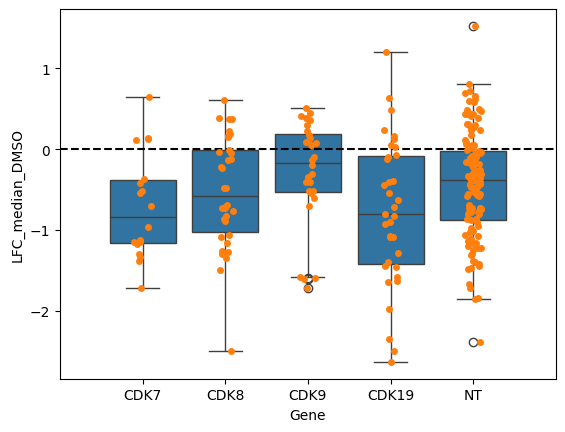

In [425]:
comparison = targ_ABE[(targ_ABE['Gene']=='NT') | (targ_ABE['gRNA_id'].isin(CDK9_high))]
sns.boxplot(data=comparison, x='Gene', y='LFC_median_DMSO')
sns.stripplot(data=comparison, x='Gene', y='LFC_median_DMSO', cmap='Reds')
plt.hlines(0, xmin=-1, xmax=5, linestyle='dashed', color='black')
plt.xlim(-1,5)
fig.tight_layout()

In [444]:
#put into bins!
#selecting guides to highlight
gene = 'CDK7'
high_edit = abe_splice_merge[abe_splice_merge['%Reads']>=10]

cutoff = 0.2

#l1 = high_edit[(high_edit['DS_AG']>=cutoff) | (high_edit['DS_AL']>=cutoff) | (high_edit['DS_DG']>=cutoff) | (high_edit['DS_DL']>=cutoff)]
bins = [[0.2,0.5], [0.5,0.8], [0.8,1]]

l1 = high_edit[(high_edit['DS_DL']>=cutoff)]
bh = []
for i, val in l1.iterrows():
    v = val['DS_DL']
    if (v>= bins[0][0]) & (v<bins[0][1]):
        bin1 = "∆0.2-0.5"
    elif (v>= bins[1][0]) & (v<bins[1][1]):
        bin1 = "∆0.5-0.8"
    elif (v>= bins[2][0]) & (v<=bins[2][1]):
        bin1 = "∆0.8-1.0"
    bh.append(bin1)

l1['bin'] = bh

l1['Gene'] = [i.split('_')[1] for i in l1['gRNA_id']]

CDK9_high = np.unique(l1['gRNA_id'])

m1 = pd.merge(l1, targ_ABE[targ_ABE['gRNA_id'].isin(CDK9_high)], on='gRNA_id')

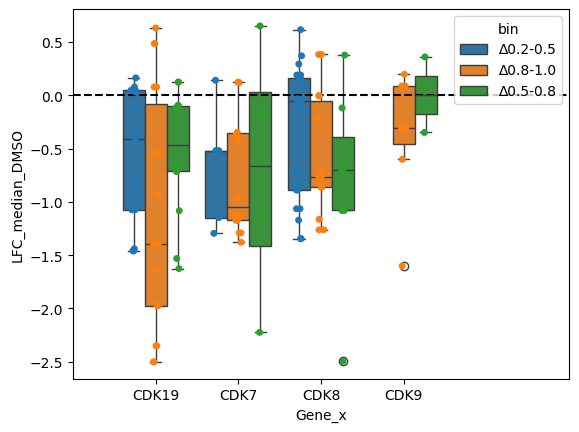

In [445]:
sns.boxplot(data=m1, x='Gene_x', y='LFC_median_DMSO', hue='bin')
sns.stripplot(data=m1, x='Gene_x', y='LFC_median_DMSO', hue='bin', dodge=True, legend=False)
plt.hlines(0, xmin=-1, xmax=5, linestyle='dashed', color='black')
plt.xlim(-1,5)
fig.tight_layout()